In [46]:
import pandas as pd
import io

In [47]:
df = pd.read_csv('/content/smart_lighting_dataset_2024.csv')

In [48]:
import numpy as np
np.random.seed(42)

df['distance_cm'] = np.where(
    df['motion_detected'] == 1,
    np.random.uniform(20, 79, size=len(df)),
    np.random.uniform(80, 400, size=len(df))
)

In [49]:
print(df.head())

             timestamp  zone_id  ambient_light_lux  motion_detected  \
0  2024-01-01 00:00:00        3               0.00                0   
1  2024-01-01 00:43:00        3              35.78                0   
2  2024-01-01 01:27:00        7               0.00                0   
3  2024-01-01 02:11:00        2               0.00                1   
4  2024-01-01 02:55:00        4               0.00                1   

   temperature_celsius  occupancy_count day_of_week time_of_day  \
0                22.08                7      Monday       Night   
1                19.19                6      Monday       Night   
2                27.78                9      Monday       Night   
3                33.11               16      Monday       Night   
4                27.07               11      Monday       Night   

  weather_condition  special_event_flag  energy_price_per_kwh  \
0            Cloudy                   0                  3.83   
1            Cloudy                   0 

In [50]:
print(df.shape)

(12000, 18)


In [51]:
print(df.columns)

Index(['timestamp', 'zone_id', 'ambient_light_lux', 'motion_detected',
       'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day',
       'weather_condition', 'special_event_flag', 'energy_price_per_kwh',
       'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed',
       'adjusted_light_intensity', 'energy_consumption_kwh',
       'lighting_action_class', 'distance_cm'],
      dtype='object')


In [52]:
#checking missing values
print(df.isnull().sum())

timestamp                     0
zone_id                       0
ambient_light_lux             0
motion_detected               0
temperature_celsius           0
occupancy_count               0
day_of_week                   0
time_of_day                   0
weather_condition             0
special_event_flag            0
energy_price_per_kwh          0
prev_hour_energy_usage_kwh    0
traffic_density               0
avg_pedestrian_speed          0
adjusted_light_intensity      0
energy_consumption_kwh        0
lighting_action_class         0
distance_cm                   0
dtype: int64


In [53]:
#Data types
print(df.dtypes)

timestamp                      object
zone_id                         int64
ambient_light_lux             float64
motion_detected                 int64
temperature_celsius           float64
occupancy_count                 int64
day_of_week                    object
time_of_day                    object
weather_condition              object
special_event_flag              int64
energy_price_per_kwh          float64
prev_hour_energy_usage_kwh    float64
traffic_density               float64
avg_pedestrian_speed          float64
adjusted_light_intensity      float64
energy_consumption_kwh        float64
lighting_action_class           int64
distance_cm                   float64
dtype: object


In [54]:
print(df.describe())

           zone_id  ambient_light_lux  motion_detected  temperature_celsius  \
count  12000.00000       12000.000000     12000.000000         12000.000000   
mean       6.53425        3708.629288         0.284083            24.964518   
std        3.48035        4656.283063         0.450996             6.260797   
min        1.00000           0.000000         0.000000           -15.870000   
25%        4.00000          55.565000         0.000000            20.970000   
50%        7.00000        2031.855000         0.000000            24.970000   
75%       10.00000        7011.792500         1.000000            29.082500   
max       12.00000      105403.500000         1.000000            64.860000   

       occupancy_count  special_event_flag  energy_price_per_kwh  \
count     12000.000000        12000.000000          12000.000000   
mean          8.557167            0.008583              5.034449   
std           8.273770            0.092252              1.272504   
min           0.

In [55]:
from sklearn.preprocessing import LabelEncoder

# Drop irrelevant columns
df = df.drop(columns=[
    'timestamp',
    'zone_id',
    'traffic_density',
    'avg_pedestrian_speed',
    'energy_price_per_kwh',
    'adjusted_light_intensity'
])

# Remove missing rows
df = df.dropna()

# Encode text columns
le_tod = LabelEncoder()
le_wc  = LabelEncoder()
le_dow = LabelEncoder()

df['time_of_day']       = le_tod.fit_transform(df['time_of_day'])
df['weather_condition'] = le_wc.fit_transform(df['weather_condition'])
df['day_of_week']       = le_dow.fit_transform(df['day_of_week'])

# Split features and target
X = df.drop('lighting_action_class', axis=1)
y = df['lighting_action_class']

print("Features used:", X.columns.tolist())
print("Dataset shape:", X.shape)

Features used: ['ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'weather_condition', 'special_event_flag', 'prev_hour_energy_usage_kwh', 'energy_consumption_kwh', 'distance_cm']
Dataset shape: (12000, 11)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9600
Testing samples: 2400


In [57]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [58]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

#Accuracy & F1
print("Accuracy: ", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score: ", round(f1_score(y_test, y_pred, average='weighted'), 4))

Accuracy:  91.5 %
F1 Score:  0.9087


In [59]:
#Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       802
           1       0.96      0.98      0.97      1402
           2       0.85      0.44      0.58       196

    accuracy                           0.92      2400
   macro avg       0.89      0.78      0.81      2400
weighted avg       0.91      0.92      0.91      2400



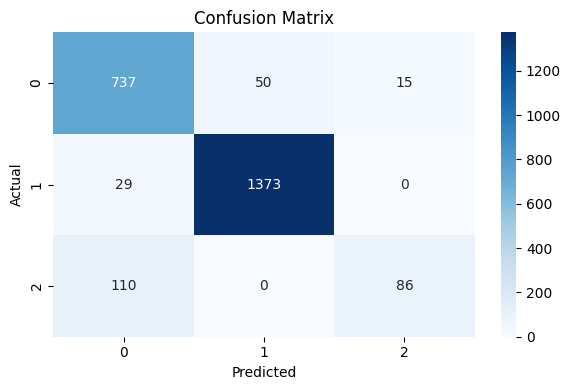

In [60]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [61]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import tensorflow as tf
import os

# Step 1: Train a simple Neural Network (TFLite needs TensorFlow model)
from tensorflow import keras

model_nn = keras.Sequential([
    keras.layers.Dense(16, activation='relu',
                       input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(len(y.unique()), activation='softmax')
])

model_nn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model_nn.fit(X_train, y_train,
             epochs=20,
             batch_size=32,
             validation_split=0.1,
             verbose=1)

# Evaluate
loss, accuracy = model_nn.evaluate(X_test, y_test)
print(f"Neural Network Accuracy: {round(accuracy*100, 2)}%")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4635 - loss: 62.4702 - val_accuracy: 0.5208 - val_loss: 0.8742
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5865 - loss: 0.8840 - val_accuracy: 0.5990 - val_loss: 0.8351
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5921 - loss: 0.8436 - val_accuracy: 0.5990 - val_loss: 0.8011
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5921 - loss: 0.8183 - val_accuracy: 0.5990 - val_loss: 0.7883
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5921 - loss: 0.7959 - val_accuracy: 0.5990 - val_loss: 0.7643
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5921 - loss: 0.7775 - val_accuracy: 0.5990 - val_loss: 0.7579
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5934 - loss: 0.7570 - val_accuracy: 0.6125 - val_loss: 0.7301
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6630 - loss: 0.7032 - val_accuracy: 0.6906 - val

In [62]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_nn)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantization
tflite_model = converter.convert()

# Save the file
tflite_filename = 'smart_lighting_model.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved: {tflite_filename}")
print(f"Model size: {round(len(tflite_model)/1024, 2)} KB")

Saved artifact at '/tmp/tmpt914owdb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133425989761360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133425989758096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133425989748688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133425989750992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133425989755984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133427882532432: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: smart_lighting_model.tflite
Model size: 3.46 KB


In [63]:
# Download the file
from google.colab import files
files.download(tflite_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>